Libraries imported successfully.
 Model loaded successfully from:
  ./Results/Trained_Models/RS42_consensus_n8_cv_safe_False_GradientBoosting_model.pkl

 Training data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n8_cv_safe_False_train_data.parquet (shape: (32, 9))
 Test data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n8_cv_safe_False_test_data.parquet (shape: (9, 9))
 Predictions made for both training and test sets.
  - Training predictions shape: (32,)
  - Test predictions shape: (9,)
╔═════════════════╦═════════════╦═════════════╗
║   Metric        ║  Train Set  ║   Test Set  ║
╠═════════════════╬═════════════╬═════════════╣
║ R² (R-squared)  ║   0.7536    ║   0.5959    ║
║ RMSE            ║   14.75      ║   23.67      ║
╚═════════════════╩═════════════╩═════════════╝


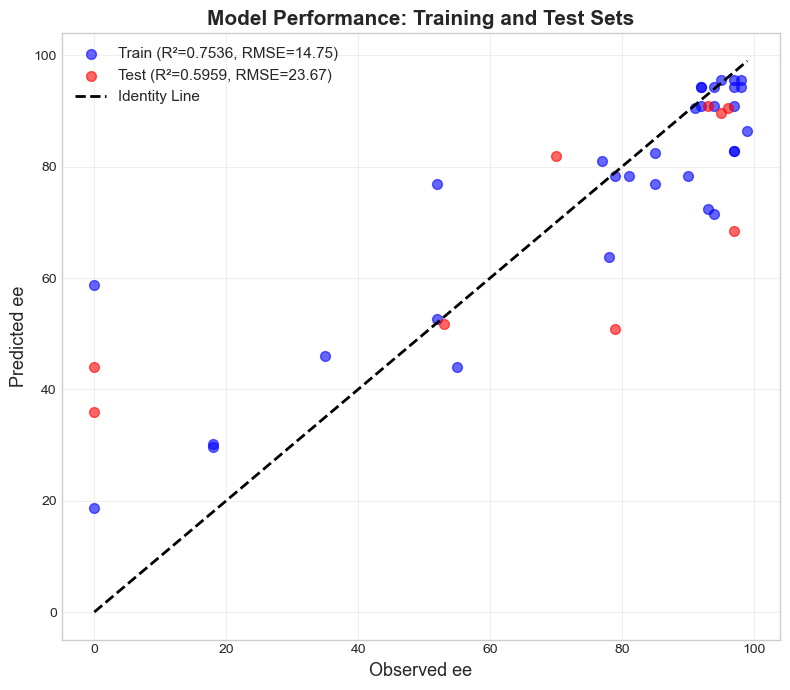

 Combined plot generated successfully


In [1]:
# # QSPR Model Verification and Visualization
# 
# This notebook loads a previously trained model and its corresponding training/test data to:
# 1.  Verify the model's performance by recalculating key metrics.
# 2.  Generate a publication-quality scatter plot of observed vs. predicted values.
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Libraries imported successfully.")

# ===================================================================
# CONFIGURATION: Specify file paths
# ===================================================================
model_path = './Results/Trained_Models/RS42_consensus_n8_cv_safe_False_GradientBoosting_model.pkl'
train_data_path = './Results/Selected_Data/RS42_consensus_n8_cv_safe_False_train_data.parquet'
test_data_path = './Results/Selected_Data/RS42_consensus_n8_cv_safe_False_test_data.parquet'

# Load the model
model = joblib.load(model_path)
print(f" Model loaded successfully from:\n  {model_path}\n")

# Load the datasets
train_df = pd.read_parquet(train_data_path)
test_df = pd.read_parquet(test_data_path)
print(f" Training data loaded successfully from:\n  {train_data_path} (shape: {train_df.shape})")
print(f" Test data loaded successfully from:\n  {test_data_path} (shape: {test_df.shape})")
# ## Prepare Data and Make Predictions

# ===================================================================
# DATA PREPARATION AND PREDICTION
# ===================================================================
# Separate features (X) and target (y)
TARGET_COLUMN = 'ee'

X_train = train_df.drop(columns=[TARGET_COLUMN])
X_train = X_train[list(train_df.iloc[:, :-1].columns)]
y_train = train_df[TARGET_COLUMN]

X_test = test_df.drop(columns=[TARGET_COLUMN])
X_test = X_test[list(train_df.iloc[:, :-1].columns)]
y_test = test_df[TARGET_COLUMN]

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(" Predictions made for both training and test sets.")
print(f"  - Training predictions shape: {y_pred_train.shape}")
print(f"  - Test predictions shape: {y_pred_test.shape}")

# ===================================================================
# PERFORMANCE VERIFICATION
# ===================================================================
# Calculate metrics for the training set
train_r2 = r2_score(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

# Calculate metrics for the test set
test_r2 = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("╔═════════════════╦═════════════╦═════════════╗")
print("║   Metric        ║  Train Set  ║   Test Set  ║")
print("╠═════════════════╬═════════════╬═════════════╣")
print(f"║ R² (R-squared)  ║   {train_r2:.4f}    ║   {test_r2:.4f}    ║")
print(f"║ RMSE            ║   {train_rmse:.2f}      ║   {test_rmse:.2f}      ║")
print("╚═════════════════╩═════════════╩═════════════╝")

# ===================================================================
# PLOT OBSERVED VS. PREDICTED (COMBINED) AND SAVE FIGURE
# ===================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Plot both training and test data on the same axes
ax.scatter(y_train, y_pred_train, c='blue', alpha=0.6, s=50, label=f'Train (R²={train_r2:.4f}, RMSE={train_rmse:.2f})')
ax.scatter(y_test, y_pred_test, c='red', alpha=0.6, s=50, label=f'Test (R²={test_r2:.4f}, RMSE={test_rmse:.2f})')

# Identity line
all_y = np.concatenate([y_train, y_test])
all_pred = np.concatenate([y_pred_train, y_pred_test])
min_val = min(all_y.min(), all_pred.min())
max_val = max(all_y.max(), all_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Identity Line')

# Labels and title
ax.set_xlabel('Observed ee', fontsize=13)
ax.set_ylabel('Predicted ee', fontsize=13)
ax.set_title('Model Performance: Training and Test Sets', fontsize=15, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('model_performance_combined.svg', format='svg', dpi=300, bbox_inches='tight')

plt.show()

print(" Combined plot generated successfully")

In [2]:
model[2]

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",30
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",1
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft c

In [3]:
## Validation set

import sys
import pandas as pd
import numpy as np
import pickle
import warnings
from pathlib import Path
from datetime import datetime

# Add module path for imports
module_path = Path('.').parent / 'module'  # Adjust if needed
if module_path.exists():
    sys.path.insert(0, str(module_path))
    print(f" Module path added: {module_path}")
else:
    print(f" Module path not found: {module_path}")
    print(f"  Current directory: {Path('.').resolve()}")
    print(f"  Please ensure calculate_descriptors.py is in a 'module' subdirectory")

warnings.filterwarnings('ignore')

# Import from your QSPR module
try:
    from calculate_descriptors import prepare_data
    print(" Successfully imported from calculate_descriptors.py")
except ImportError as e:
    print(f" Error importing from models_creation.py: {e}")
    raise

print("\n All imports successful")

 Module path added: module

╔════════════════════════════════════════════════════════════════════════════╗
║                                                                            ║
║                calculate_descriptors.py MODULE READY                       ║
║                                                                            ║
║         Import this module in your QSPR analysis scripts                   ║
║         Location: module/calculate_descriptors.py                          ║
║                                                                            ║
╚════════════════════════════════════════════════════════════════════════════╝
    
 Successfully imported from calculate_descriptors.py

 All imports successful


In [4]:
CONFIG = {
    # Data file
    'data': './Data/model_reg_val.xlsx',
    'target_col': 'ee',
    'name': 'validation_set',
    'mode': 'validation',
    'output_dir': './Data/'
}

In [5]:
# ============================================================================
# SECTION 3: LOAD DATA & CALCULATE ALL DESCRIPTORS
# ============================================================================

print('\n' + "█"*75)
print("█" + " STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS ".center(73) + "█")
print("█"*75)

print(f"\nLoading data from: {CONFIG['data']}")
print(f"Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic")
print(f"This may take 5-15 minutes depending on dataset size...")

try:
    # Calculate ALL descriptors (full set)
    data = prepare_data(
        CONFIG['data'],
        CONFIG['target_col'],
        CONFIG['name'],
        CONFIG['mode'],
        CONFIG['output_dir'],
       
    )
    
    print(f"\n Data loaded and ALL descriptors calculated")
    print(f"  Total samples: {data.shape[0]}")
    print(f"  Total features: {data.shape[1]-1} (+ target)")
    print(f"  Target range: [{data[CONFIG['target_col']].min():.1f}, {data[CONFIG['target_col']].max():.1f}]")
    print(f"  Target mean: {data[CONFIG['target_col']].mean():.2f}")
    print(f"  Target std: {data[CONFIG['target_col']].std():.2f}")
    
except Exception as e:
    print(f"\n Error loading data: {e}")
    print(f"\n  Try these solutions:")
    print(f"  1. Check if {CONFIG['data']} exists")
    print(f"  2. Verify path is correct (relative or absolute)")
    print(f"  3. Check if models_creation.py is accessible")
    raise


███████████████████████████████████████████████████████████████████████████
█              STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS              █
███████████████████████████████████████████████████████████████████████████

Loading data from: ./Data/model_reg_val.xlsx
Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic
This may take 5-15 minutes depending on dataset size...

LOADING DATA FOR UNIFIED DESCRIPTOR CALCULATION
  DESCRIPTOR PIPELINE:
 Mordred: True
 Morgan FP: True
 Sterimol + Electronic: True
 ChemBERTa: False
 CircuS: True
 ChyLine: True

---------------------------------------------------------------------------
Calculating/Cleaning descriptors ...
---------------------------------------------------------------------------
SUCCESS: Loaded CLEANED descriptors from Data\molecular_descriptors_cleaned_validation_set_.parquet
Shape: (5, 4006)
Returning: full descriptor set

 Data loaded and ALL descriptors calculated
  Total samples: 5
 

In [6]:
X_train.columns

Index(['ATS5s', 'ATS3i', 'AMID_C', 'AATSC4i', 'nRot', 'Sterimol_Beta_R1_B5',
       'ATSC7Z', 'GATS3d'],
      dtype='object')

In [7]:
data[list(X_train.columns)]

,ATS5s,ATS3i,AMID_C,AATSC4i,nRot,Sterimol_Beta_R1_B5,ATSC7Z,GATS3d
0,132.576132,8747.374275,1.807555,-0.102342,3,5.664895,-58.50000,1.138455
1,18.000000,5726.677491,1.704497,-0.019827,0,4.489580,0.00000,0.976744
2,135.493827,8748.849206,1.806973,-0.105136,3,5.656536,21.50000,1.237451
3,165.388889,9836.662395,1.859580,-0.056182,3,7.270605,29.71384,1.158518
4,131.333333,10490.571111,1.839663,-0.004409,5,4.858933,-30.52000,1.034619


In [8]:
y_pred_val = model.predict(data[list(X_train.columns)])

In [9]:
y_pred_val

array([90.94490838, 50.85921648, 84.09390368, 91.90100651, 46.38420625])

In [10]:
y_pred_val[0]

np.float64(90.94490837842841)

In [11]:
data['ee']

0    93
1    44
2    88
3    99
4    88
Name: ee, dtype: int64

In [12]:
# Calculate metrics for the validation set
val_r2 = r2_score(data['ee'], y_pred_val)
val_rmse = np.sqrt(mean_squared_error(data['ee'], y_pred_val))

In [13]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  Validation Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {val_r2:.4f}                  ║")
print(f"║ RMSE            ║   {val_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

╔═════════════════╦═══════════════════════════╗
║   Metric        ║  Validation Set           ║
╠═════════════════╬═══════════════════════════╣
║ R² (R-squared)  ║   0.0397                  ║
║ RMSE            ║   19.23                   ║
╚═════════════════╩═══════════════════════════╝


In [14]:


for x in range(len(y_pred_val)):

    print("Observed ee: " + str(data['ee'][x]) + '   ' + "Predicted ee: " +str(y_pred_val[x]))

Observed ee: 93   Predicted ee: 90.94490837842841
Observed ee: 44   Predicted ee: 50.85921647827468
Observed ee: 88   Predicted ee: 84.09390367988935
Observed ee: 99   Predicted ee: 91.90100650841009
Observed ee: 88   Predicted ee: 46.38420625337371


In [15]:
validation_data = './Data/model_reg_val.xlsx'


# Load the datasets
val_df = pd.read_excel(validation_data)
val_df.head(1)

,Reaction ID,Reaction: Links to Reaxys,Reactant,Product,Bin,SMILES_product,SMILES,Reaction,Number of Reaction Steps,Time (Reaction Details) [h],...,Reagent,SMILES ligand,SMILES mieszanina reakcyjna,% mol liganda,% mol magnezu,stężenie katalizatora [mol/dm3],stężenie substratu M,Solvent (Reaction Details),References,Links to Reaxys
0,28833233,https://www.reaxys.com/reaxys/secured/hopinto....,4'-chlorochalcone,"trans-(2R,3S)-2,3-epoxy-3-phenyl-1-(4-chloroph...",122716,ClC3=CC=C(C([C@@H]4O[C@H]4C5=CC=CC=C5)=O)C=C3,ClC1=CC=C(C(/C=C/C2=CC=CC=C2)=O)C=C1,ClC1=CC=C(C(/C=C/C2=CC=CC=C2)=O)C=C1>>ClC3=CC=...,1,72,...,"tert.-butylhydroperoxide; (R,R)-(-)-2,6-bis[2-...",OC(C1=CC=CC=C1)(C2=CC=CC=C2)[C@@H](CCC3)N3CC4=...,CC(C)(OO)C.OC(C1=CC=CC=C1)(C2=CC=CC=C2)[C@@H](...,12,20,0.024,0.2,tetrahydrofuran; toluene,"Article; Jaszczewska-Adamczak, Joanna A.; Mlyn...",https://www.reaxys.com/reaxys/secured/hopinto....


Observed ee: 93   Predicted ee: 90.94490837842841


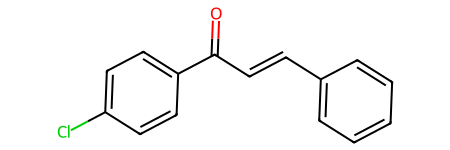

Observed ee: 44   Predicted ee: 50.85921647827468


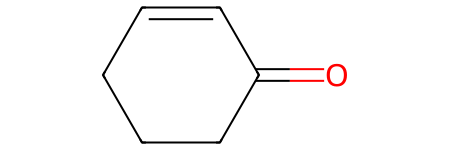

Observed ee: 88   Predicted ee: 84.09390367988935


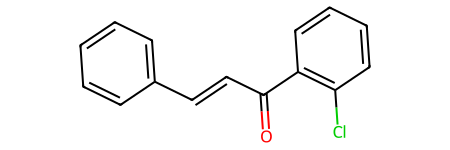

Observed ee: 99   Predicted ee: 91.90100650841009


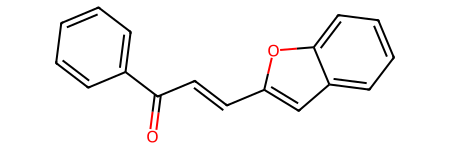

Observed ee: 88   Predicted ee: 46.38420625337371


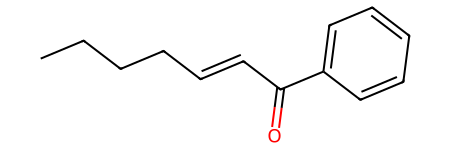

In [16]:

from rdkit import Chem
from IPython.display import display

for x in range(len(y_pred_val)):
    print("Observed ee: " + str(data['ee'][x]) + '   ' + "Predicted ee: " + str(y_pred_val[x]))
    mol = Chem.MolFromSmiles(val_df['SMILES'][x])
    display(mol)


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial import Delaunay
import warnings
warnings.filterwarnings('ignore')


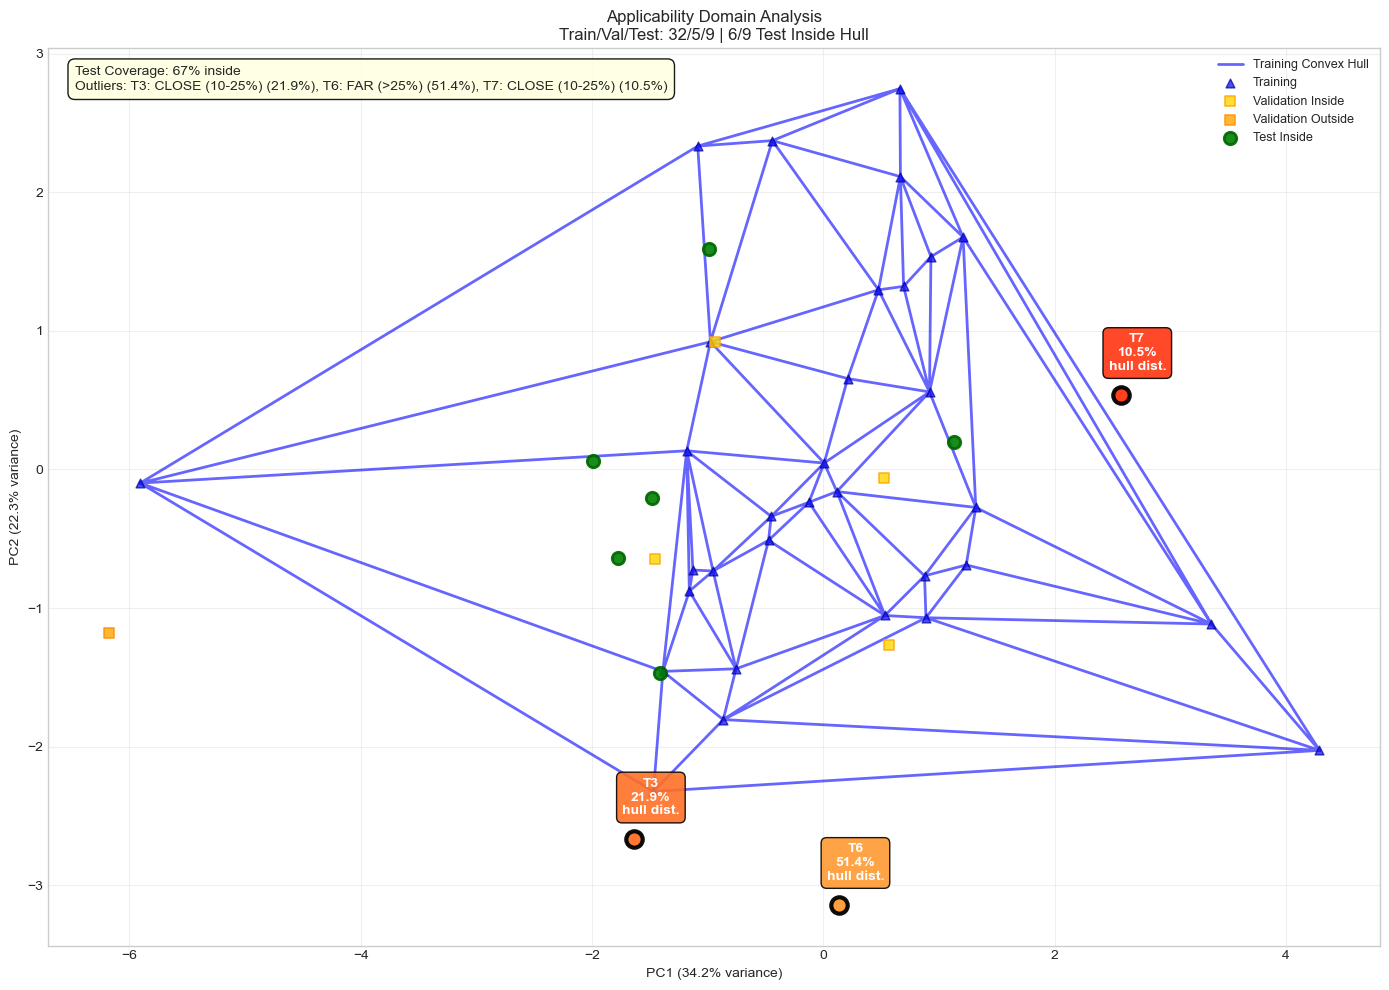

Outlier Analysis:
  T3: CLOSE (10-25%) (21.9%)
  T6: FAR (>25%) (51.4%)
  T7: CLOSE (10-25%) (10.5%)

Summary: 6/9 test points inside hull (66.7%)
Detailed outlier info: {'T3': {'dist_to_hull': np.float64(0.3832096519106858), 'dist_to_edge': np.float64(0.3832096519106858), 'dist_to_vertex': np.float64(0.3832096519106858), 'hull_radius': np.float64(1.7464487166002187), 'relative_dist_%': np.float64(21.942221851018527)}, 'T6': {'dist_to_hull': np.float64(0.898529714803769), 'dist_to_edge': np.float64(0.898529714803769), 'dist_to_vertex': np.float64(1.6678594667054731), 'hull_radius': np.float64(1.7464487166002187), 'relative_dist_%': np.float64(51.44896075465194)}, 'T7': {'dist_to_hull': np.float64(0.18304881524965586), 'dist_to_edge': np.float64(0.18304881524965586), 'dist_to_vertex': np.float64(1.492516118029625), 'hull_radius': np.float64(1.7464487166002187), 'relative_dist_%': np.float64(10.48120185320951)}}


In [18]:
def analyze_applicability_detailed(X_train, X_val, X_test):
    """Single plot version"""
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test) 
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    from scipy.spatial import Delaunay
    tri = Delaunay(X_train_pca)
    
    # Masks
    val_inside_mask = tri.find_simplex(X_val_pca) >= 0
    test_inside_mask = tri.find_simplex(X_test_pca) >= 0

    # Distance calculation
    def point_to_hull_distance(point, tri, X_train_pca):
        """Stable distance to convex hull"""
        min_dist = np.inf
        
        # 1. To vertices
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        # 2. To edges
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0,1], [1,2], [2,0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        center = np.mean(X_train_pca, axis=0)
        hull_radius = np.mean(np.linalg.norm(X_train_pca - center, axis=1))
        
        total_min_dist = min(dist_vertices, min_edge_dist)
        
        return {
            'dist_to_hull': total_min_dist,
            'dist_to_edge': min_edge_dist,
            'dist_to_vertex': dist_vertices,
            'hull_radius': hull_radius,
            'relative_dist_%': (total_min_dist / hull_radius) * 100
        }

    # Analyze outliers
    outlier_info = {}
    outlier_descriptions = []
    for i, is_inside in enumerate(test_inside_mask):
        if not is_inside:
            info = point_to_hull_distance(X_test_pca[i], tri, X_train_pca)
            outlier_info[f'T{i}'] = info
            
            # English classification
            rel_dist = info['relative_dist_%']
            if rel_dist < 10:
                desc = "VERY CLOSE (<10%)"
            elif rel_dist < 25:
                desc = "CLOSE (10-25%)"
            else:
                desc = "FAR (>25%)"
            
            outlier_descriptions.append(f"T{i}: {desc} ({rel_dist:.1f}%)")

    # SINGLE PLOT - FULL FEATURES
    plt.figure(figsize=(14, 10))
    
    # Convex hull
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, 
                'b-', alpha=0.6, linewidth=2, label='Training Convex Hull')

    # Training points
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='blue', s=40, 
                alpha=0.7, marker='^', edgecolors='darkblue', label='Training')

    # Validation points
    plt.scatter(X_val_pca[val_inside_mask, 0], X_val_pca[val_inside_mask, 1], 
                c='gold', s=60, marker='s', alpha=0.8, 
                edgecolors='orange', label='Validation Inside', linewidth=1.2)
    if np.any(~val_inside_mask):
        plt.scatter(X_val_pca[~val_inside_mask, 0], X_val_pca[~val_inside_mask, 1], 
                    c='orange', s=60, marker='s', alpha=0.8, 
                    edgecolors='darkorange', label='Validation Outside', linewidth=1.2)

    # Test inside
    plt.scatter(X_test_pca[test_inside_mask, 0], X_test_pca[test_inside_mask, 1], 
                c='green', s=80, alpha=0.9, edgecolors='darkgreen', 
                label='Test Inside', linewidth=2)

    # Test outside WITH DISTANCES
    test_outside_idx = np.where(~test_inside_mask)[0]
    for i, idx in enumerate(test_outside_idx):
        dist_pct = outlier_info[f'T{idx}']['relative_dist_%']
        color_intensity = min(dist_pct / 30, 1)
        color = (1, color_intensity*0.6, color_intensity*0.2)  # Red gradient
        
        plt.scatter(X_test_pca[idx, 0], X_test_pca[idx, 1], 
                   c=color, s=140, alpha=0.95, edgecolors='black', linewidth=3)
        
        # Distance annotation
        plt.annotate(f'T{idx}\n{dist_pct:.1f}%\nhull dist.', 
                    (X_test_pca[idx, 0], X_test_pca[idx, 1]), 
                    xytext=(12, 18), textcoords='offset points', fontsize=10,
                    color='white', fontweight='bold', ha='center',
                    bbox=dict(boxstyle="round,pad=0.4", facecolor=color, alpha=0.9))

    # Title and labels
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.title(f'Applicability Domain Analysis\n'
              f'Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)} | '
              f'{np.sum(test_inside_mask)}/{len(test_inside_mask)} Test Inside Hull')
    
    # Legend with outlier summary
    legend_text = f"Test Coverage: {100*np.sum(test_inside_mask)/len(test_inside_mask):.0f}% inside"
    if outlier_descriptions:
        legend_text += f"\nOutliers: {', '.join(outlier_descriptions)}"
    
    plt.text(0.02, 0.98, legend_text, transform=plt.gca().transAxes, 
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='lightyellow', alpha=0.9))
    
    plt.legend(loc='upper right', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save publication-ready
    plt.savefig('applicability_domain_single_plot.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('applicability_domain_single_plot.png', dpi=300, bbox_inches='tight')
    plt.savefig('applicability_domain_single_plot.svg', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Outlier Analysis:")
    for desc in outlier_descriptions:
        print(f"  {desc}")
    print(f"\nSummary: {np.sum(test_inside_mask)}/{len(test_inside_mask)} test points inside hull "
          f"({100*np.sum(test_inside_mask)/len(test_inside_mask):.1f}%)")
    
    return {
        'test_inside_mask': test_inside_mask,
        'val_inside_mask': val_inside_mask,
        'outlier_info': outlier_info,
        'outlier_descriptions': outlier_descriptions
    }

# USAGE:
result = analyze_applicability_detailed(X_train, data[list(X_train.columns)], X_test)
print("Detailed outlier info:", result['outlier_info'])


In [19]:
def analyze_applicability_heuristic(X_train, X_val, X_test, heuristic_threshold=0.1):
    """
    Analyzes Applicability Domain with Convex Hull and Distance Heuristic.
    
    Heuristic Logic:
    - Inside Hull -> In Domain
    - Outside Hull:
        - rel_dist = dist_to_hull / dist_to_centroid
        - if rel_dist < threshold -> In Domain (Extended)
        - if rel_dist >= threshold -> Out of Domain
    """
    
    # 1. Preprocessing & PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test) 
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 2. Convex Hull (Delaunay)
    tri = Delaunay(X_train_pca)
    
    # Basic containment check
    val_inside_mask = tri.find_simplex(X_val_pca) >= 0
    test_inside_mask = tri.find_simplex(X_test_pca) >= 0
    
    # Geometric center of training data (Centroid)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Helper: Distance to Hull Calculation
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        # A. Distance to Hull (Geometric approach)
        # 1. To vertices
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        # 2. To edges
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0,1], [1,2], [2,0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        r_d_hull = min(dist_vertices, min_edge_dist)
        
        # B. Distance to Geometric Center (Centroid)
        r_geometrical_center = np.linalg.norm(point - centroid)
        
        # C. Heuristic Ratio
        # Avoid division by zero
        rel_distance = r_d_hull / r_geometrical_center if r_geometrical_center > 1e-9 else 0
        
        return {
            'r_d_hull': r_d_hull,
            'r_geometrical_center': r_geometrical_center,
            'rel_distance': rel_distance
        }

    # 4. Analyze Test Points with Heuristic
    test_status = [] # 'inside', 'extended', 'out'
    outlier_details = {}
    
    for i in range(len(X_test_pca)):
        if test_inside_mask[i]:
            test_status.append('inside')
        else:
            # Calculate heuristic metrics
            info = get_hull_distance_info(X_test_pca[i], tri, X_train_pca, centroid_train)
            rel_dist = info['rel_distance']
            
            outlier_details[f'T{i}'] = info
            
            if rel_dist < heuristic_threshold:
                test_status.append('extended') # Outside hull but acceptable
            else:
                test_status.append('out') # Outside hull and unacceptable

    test_status = np.array(test_status)

    # 5. PLOTTING
    plt.figure(figsize=(12, 9))
    
    # A. Draw Hull
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, 
                color='gray', alpha=0.4, linewidth=1, label='Training Convex Hull')

    # B. Plot Points
    # Training
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='blue', s=30, 
                alpha=0.5, marker='o', label='Training Data')

    # Validation (Optional visualization)
    plt.scatter(X_val_pca[:, 0], X_val_pca[:, 1], c='orange', s=30, marker='s', alpha=0.6, label='Validation')

    # Test: Inside Hull (Safe)
    mask_in = test_status == 'inside'
    if np.any(mask_in):
        plt.scatter(X_test_pca[mask_in, 0], X_test_pca[mask_in, 1], 
                   c='green', s=80, alpha=0.9, edgecolors='darkgreen', 
                   label='Test: Inside Hull (Safe)')

    # Test: Extended Domain (Heuristic Acceptable)
    mask_ext = test_status == 'extended'
    if np.any(mask_ext):
        plt.scatter(X_test_pca[mask_ext, 0], X_test_pca[mask_ext, 1], 
                   c='yellowgreen', s=100, marker='D', alpha=0.9, edgecolors='black', 
                   label=f'Test: Extended Domain (rel_dist < {heuristic_threshold})')
        
        # Annotate extended points
        for idx in np.where(mask_ext)[0]:
            info = outlier_details[f'T{idx}']
            plt.annotate(f"T{idx}\n{info['rel_distance']:.2f}", 
                         (X_test_pca[idx, 0], X_test_pca[idx, 1]),
                         xytext=(0, 10), textcoords='offset points', ha='center', fontsize=8)

    # Test: Out of Domain
    mask_out = test_status == 'out'
    if np.any(mask_out):
        plt.scatter(X_test_pca[mask_out, 0], X_test_pca[mask_out, 1], 
                   c='red', s=120, marker='X', alpha=0.9, edgecolors='black', 
                   label=f'Test: Out of Domain (rel_dist >= {heuristic_threshold})')

        # Annotate outliers
        for idx in np.where(mask_out)[0]:
            info = outlier_details[f'T{idx}']
            plt.annotate(f"T{idx}\n{info['rel_distance']:.2f}", 
                         (X_test_pca[idx, 0], X_test_pca[idx, 1]),
                         xytext=(0, 10), textcoords='offset points', ha='center', 
                         color='red', fontweight='bold', fontsize=9)

    # Plot Centroid
    plt.scatter(centroid_train[0], centroid_train[1], c='black', marker='+', s=200, linewidth=2, label='Train Centroid')

    # Formatting
    plt.title(f'Applicability Domain Analysis (Heuristic Threshold = {heuristic_threshold})\n'
              f'Total Test: {len(X_test)} | Safe: {np.sum(mask_in)} | '
              f'Extended: {np.sum(mask_ext)} | Outliers: {np.sum(mask_out)}')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
    plt.legend(loc='upper right', frameon=True, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save
    plt.savefig('AD_heuristic_plot.png', dpi=300)
    plt.savefig('AD_heuristic_plot.svg', dpi=300)
    plt.show()

    # Text Summary
    print("-" * 50)
    print("HEURISTIC SUMMARY")
    print("-" * 50)
    print(f"Threshold (rel_distance): {heuristic_threshold}")
    print(f"Inside Hull (Safe):       {np.sum(mask_in)}")
    print(f"Extended Domain (Safe):   {np.sum(mask_ext)}")
    print(f"Out of Domain (Unsafe):   {np.sum(mask_out)}")
    print("-" * 50)
    
    if len(outlier_details) > 0:
        print("\nDetails for points outside hull:")
        print(f"{'ID':<5} | {'r_hull':<10} | {'r_center':<10} | {'rel_dist':<10} | {'Status'}")
        for idx_str, info in outlier_details.items():
            status = "EXTENDED" if info['rel_distance'] < heuristic_threshold else "OUT"
            print(f"{idx_str:<5} | {info['r_d_hull']:.4f}     | {info['r_geometrical_center']:.4f}     | {info['rel_distance']:.4f}     | {status}")

    return {
        'test_status': test_status,
        'outlier_details': outlier_details,
        'mask_in': mask_in,
        'mask_extended': mask_ext,
        'mask_out': mask_out
    }

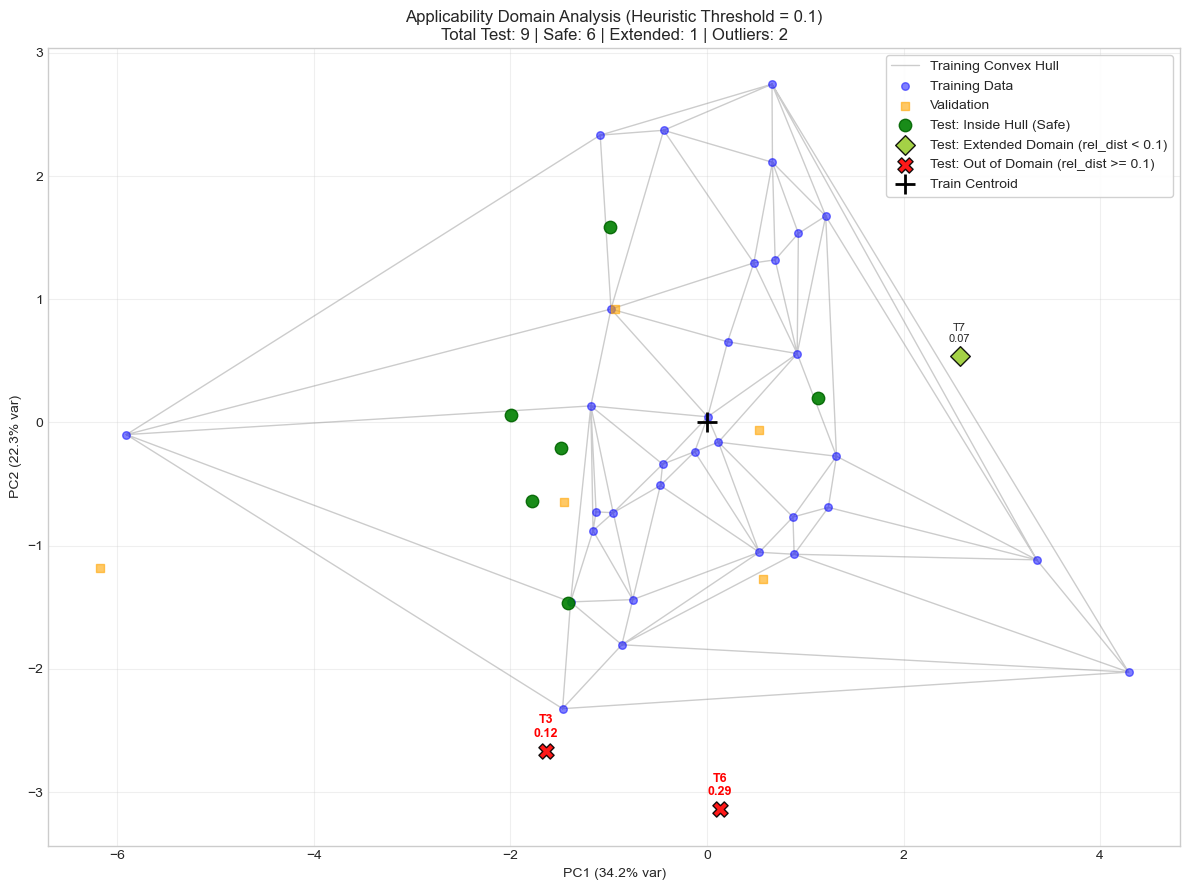

--------------------------------------------------
HEURISTIC SUMMARY
--------------------------------------------------
Threshold (rel_distance): 0.1
Inside Hull (Safe):       6
Extended Domain (Safe):   1
Out of Domain (Unsafe):   2
--------------------------------------------------

Details for points outside hull:
ID    | r_hull     | r_center   | rel_dist   | Status
T3    | 0.3832     | 3.1298     | 0.1224     | OUT
T6    | 0.8985     | 3.1431     | 0.2859     | OUT
T7    | 0.1830     | 2.6249     | 0.0697     | EXTENDED


In [20]:
result = analyze_applicability_heuristic(X_train, data[list(X_train.columns)], X_test, heuristic_threshold=0.1)

In [21]:
CONFIG = {
    # Data file
    'data': './Data/exp_verification.xlsx',
    'target_col': 'ee',
    'name': 'exp_set',
    'mode': 'exp',
    'output_dir': './Data/'
}

In [22]:
# ============================================================================
# SECTION 3: LOAD DATA & CALCULATE ALL DESCRIPTORS
# ============================================================================

print('\n' + "█"*75)
print("█" + " STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS ".center(73) + "█")
print("█"*75)

print(f"\nLoading data from: {CONFIG['data']}")
print(f"Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic")
print(f"This may take 5-15 minutes depending on dataset size...")

try:
    # Calculate ALL descriptors (full set)
    data = prepare_data(
        CONFIG['data'],
        CONFIG['target_col'],
        CONFIG['name'],
        CONFIG['mode'],
        CONFIG['output_dir'],
       
    )
    
    print(f"\n Data loaded and ALL descriptors calculated")
    print(f"  Total samples: {data.shape[0]}")
    print(f"  Total features: {data.shape[1]-1} (+ target)")
    print(f"  Target range: [{data[CONFIG['target_col']].min():.1f}, {data[CONFIG['target_col']].max():.1f}]")
    print(f"  Target mean: {data[CONFIG['target_col']].mean():.2f}")
    print(f"  Target std: {data[CONFIG['target_col']].std():.2f}")
    
except Exception as e:
    print(f"\n Error loading data: {e}")
    print(f"\n  Try these solutions:")
    print(f"  1. Check if {CONFIG['data']} exists")
    print(f"  2. Verify path is correct (relative or absolute)")
    print(f"  3. Check if models_creation.py is accessible")
    raise


███████████████████████████████████████████████████████████████████████████
█              STEP 1: LOAD DATA & CALCULATE ALL DESCRIPTORS              █
███████████████████████████████████████████████████████████████████████████

Loading data from: ./Data/exp_verification.xlsx
Calculating all descriptors: Mordred, Morgan, CircuS, ChemBERTa, Sterimol, Electronic
This may take 5-15 minutes depending on dataset size...

LOADING DATA FOR UNIFIED DESCRIPTOR CALCULATION
  DESCRIPTOR PIPELINE:
 Mordred: True
 Morgan FP: True
 Sterimol + Electronic: True
 ChemBERTa: False
 CircuS: True
 ChyLine: True

---------------------------------------------------------------------------
Calculating/Cleaning descriptors ...
---------------------------------------------------------------------------
No cache found. Calculating descriptors from scratch...

---------------------------------------------------------------------------
Canonicalizing SMILES & Generating 3D Conformers
----------------------------

100%|██████████████████████████████████████████████████████████████████████████████████| 12/12 [00:01<00:00,  8.89it/s]


 OK: Mordred: (12, 1826)
 >> Calculating Morgan fingerprints...
 OK: Morgan FP: (12, 2048)
 >> Calculating Reactive C=C Sterimol & Electronic descriptors...
 OK: Added 23 C=C features
>> Calculating CircuS/ChyLine descriptors...
OK: CircuS descriptor available
OK: ChyLine descriptor available
 CircuS features: (12, 114)
 ChyLine features: (12, 61)
OK: Generated 175 fragment features
 - CircuS: 114
 - ChyLine: 61
Raw descriptors shape: (12, 4072)
Raw descriptors cached: Data\molecular_descriptors_raw_exp_set_.parquet
No NaN cleaning was performed...
OK: descriptors cached: Data\molecular_descriptors_cleaned_exp_set_.parquet

DESCRIPTOR CALCULATION SUMMARY
Final shape: 12 samples × 4072 features
Target: ee
Output dir: Data
Returning: full descriptor set

 Data loaded and ALL descriptors calculated
  Total samples: 12
  Total features: 4072 (+ target)
  Target range: [5.0, 99.0]
  Target mean: 77.25
  Target std: 33.16


In [23]:
data[list(X_train.columns)]

,ATS5s,ATS3i,AMID_C,AATSC4i,nRot,Sterimol_Beta_R1_B5,ATSC7Z,GATS3d
0,168.814815,9813.849114,1.820925,-0.167162,4,5.657088,144.476562,1.227520
1,134.370370,8694.181498,1.806973,-0.136091,3,5.656860,59.795918,1.237451
2,132.348765,8694.181498,1.806876,-0.135418,3,5.635287,59.795918,1.237451
3,233.481481,11282.809066,1.667788,0.110417,6,7.136179,93.060487,1.413043
4,258.388889,13275.115138,1.678118,0.014147,6,10.560023,14.124331,1.136456
5,254.333333,14524.474089,1.679800,0.101721,6,8.632473,83.380952,0.984153
6,143.796296,9492.497442,1.810301,-0.142227,3,6.874620,-170.579605,1.096698
7,301.027778,9845.072761,1.652118,-0.803920,3,5.670329,53.908429,1.241594
8,161.500000,9492.667877,1.812017,-0.220072,4,5.663913,-40.980469,1.317460
9,157.666667,9771.362821,1.810301,-0.082216,3,6.040328,-99.099896,1.096698


In [24]:
y_pred_exp = model.predict(data[list(X_train.columns)])

In [25]:
# Calculate metrics for the validation set
exp_r2 = r2_score(data['ee'], y_pred_exp)
exp_rmse = np.sqrt(mean_squared_error(data['ee'], y_pred_exp))

In [26]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  EXP Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {exp_r2:.4f}                  ║")
print(f"║ RMSE            ║   {exp_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

╔═════════════════╦═══════════════════════════╗
║   Metric        ║  EXP Set           ║
╠═════════════════╬═══════════════════════════╣
║ R² (R-squared)  ║   0.3191                  ║
║ RMSE            ║   26.20                   ║
╚═════════════════╩═══════════════════════════╝


In [27]:


for x in range(len(y_pred_exp)):

    print("Observed ee: " + str(data['ee'][x]) + '   ' + "Predicted ee: " +str(y_pred_exp[x]))

Observed ee: 92   Predicted ee: 81.53295750269378
Observed ee: 89   Predicted ee: 82.78976749990788
Observed ee: 11   Predicted ee: 42.70407559975416
Observed ee: 87   Predicted ee: 63.66863741595181
Observed ee: 90   Predicted ee: 78.24819108184134
Observed ee: 91   Predicted ee: 78.24819108184134
Observed ee: 94   Predicted ee: 89.64077219844694
Observed ee: 72   Predicted ee: 72.90725755977049
Observed ee: 99   Predicted ee: 62.41718179301298
Observed ee: 98   Predicted ee: 90.94490837842841
Observed ee: 5   Predicted ee: 73.3639309880503
Observed ee: 99   Predicted ee: 86.46989815352747


In [28]:
exp_data = './Data/exp_verification.xlsx'


# Load the datasets
exp_df = pd.read_excel(exp_data)
exp_df.head(1)

,l.p,SMILES,SMILES_product,ee
0,10,C=CC1=CC(/C=C/C(C2=C(C=CC=C2)Br)=O)=CC=C1,C=CC1=CC([C@@H]2O[C@H]2C(C3=C(Br)C=CC=C3)=O)=C...,92


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def analyze_applicability_heuristic(X_train, X_val, X_test, heuristic_threshold=0.1):
    """
    Analyzes Applicability Domain with Convex Hull and Distance Heuristic.
    Returns dictionaries containing processed DataFrames for Experimental (Val) and Test sets,
    printing indices of molecules outside the safe domain.
    """
    
    # 1. Preprocessing & PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test) 
    
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 2. Convex Hull (Delaunay) on Training Data
    tri = Delaunay(X_train_pca)
    centroid_train = np.mean(X_train_pca, axis=0)

    # 3. Helper: Distance to Hull Calculation
    def get_hull_distance_info(point, tri, X_train_pca, centroid):
        # A. Distance to Hull (Geometric approach)
        dist_vertices = np.min(np.linalg.norm(X_train_pca - point, axis=1))
        
        min_edge_dist = np.inf
        for simplex in tri.simplices:
            for edge in [[0,1], [1,2], [2,0]]:
                p1 = X_train_pca[simplex[edge[0]]]
                p2 = X_train_pca[simplex[edge[1]]]
                
                edge_vec = p2 - p1
                point_vec = point - p1
                edge_len2 = np.dot(edge_vec, edge_vec)
                
                if edge_len2 != 0:
                    proj = np.dot(point_vec, edge_vec) / edge_len2
                    proj = np.clip(proj, 0, 1)
                    closest = p1 + proj * edge_vec
                    dist = np.linalg.norm(point - closest)
                    min_edge_dist = min(min_edge_dist, dist)
                else:
                    min_edge_dist = min(min_edge_dist, np.linalg.norm(point - p1))
        
        r_d_hull = min(dist_vertices, min_edge_dist)
        
        # B. Distance to Geometric Center (Centroid)
        r_geometrical_center = np.linalg.norm(point - centroid)
        
        # C. Heuristic Ratio
        rel_distance = r_d_hull / r_geometrical_center if r_geometrical_center > 1e-9 else 0
        
        return rel_distance

    # 4. Universal Function to Process Any Dataset
    def process_dataset(X_data, X_pca_data, dataset_name="Data"):
        if isinstance(X_data, pd.DataFrame):
            df_out = X_data.copy()
            
            indices = X_data.index.tolist()
        else:
            df_out = pd.DataFrame(X_data)
            indices = list(range(len(X_data)))
            
        is_inside = tri.find_simplex(X_pca_data) >= 0
        
        status_list = []
        rel_dist_list = []
        
        for i in range(len(X_pca_data)):
            if is_inside[i]:
                status_list.append('Inside Hull')
                rel_dist_list.append(0.0) 
            else:
                rel_dist = get_hull_distance_info(X_pca_data[i], tri, X_train_pca, centroid_train)
                rel_dist_list.append(rel_dist)
                
                if rel_dist < heuristic_threshold:
                    status_list.append('Extended Domain')
                else:
                    status_list.append('Out of Domain')
        
        df_out['AD_Status'] = status_list
        df_out['Rel_Distance'] = rel_dist_list
        # Dodajemy kolumnę pomocniczą z indeksem do łatwego dostępu
        df_out['Original_Index'] = indices
        
        return df_out, np.array(status_list)

    # 5. Apply Logic
    print("Processing Experimental Data...")
    X_val_df, val_statuses = process_dataset(X_val, X_val_pca, "Experimental")
    
    X_val_df["Original_Index"] = X_val_df["Original_Index"] + 1
    
    print("Processing Test Data...")
    X_test_df, test_statuses = process_dataset(X_test, X_test_pca, "Test")

    # 6. PLOTTING
    plt.figure(figsize=(12, 9))
    
    plt.triplot(X_train_pca[:, 0], X_train_pca[:, 1], tri.simplices, color='gray', alpha=0.4)
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='blue', alpha=0.3, label='Training Data')
    plt.scatter(centroid_train[0], centroid_train[1], c='black', marker='+', s=200, label='Centroid')

    style_map = {
        'Inside Hull':     {'c': 'green', 'm': 'o', 'alpha': 0.6},
        'Extended Domain': {'c': 'orange', 'm': 'D', 'alpha': 0.8},
        'Out of Domain':   {'c': 'red',   'm': 'X', 'alpha': 0.9}
    }

    # Helper function to plot and annotate
    def plot_subset(df, pca_data, label_prefix, marker_style):
        for status in style_map:
            mask = df['AD_Status'] == status
            if mask.any():
                plt.scatter(pca_data[mask, 0], pca_data[mask, 1], 
                            c=style_map[status]['c'], marker=marker_style, s=60, edgecolors='black',
                            label=f'{label_prefix}: {status}')
                
                # Annotation for non-Inside points
                if status in ['Out of Domain', 'Extended Domain']:
                    idxs = np.where(mask)[0]
                    for idx in idxs:
                        dist = df.iloc[idx]['Rel_Distance']
                        mol_idx = df.iloc[idx]['Original_Index']
                        
                        #"Index: Distance annotation format"
                        label_text = f"#{mol_idx}\n{dist:.2f}"
                        
                        plt.annotate(label_text, 
                                     (pca_data[idx, 0], pca_data[idx, 1]),
                                     xytext=(5, 5), textcoords='offset points', 
                                     fontsize=8, fontweight='bold', color='black',
                                     bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

    plot_subset(X_val_df, X_val_pca, "Exp", 's')
    plot_subset(X_test_df, X_test_pca, "Test", 'P')

    plt.title(f'Applicability Domain (Threshold={heuristic_threshold})')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('AD_heuristic_plot_experimental.svg', dpi=300)
    plt.show()

    # 7. Summary Print with Indices
    def print_outliers(df, name):
        print(f"\n--- Detailed Report: {name} Set ---")
        counts = df['AD_Status'].value_counts()
        print(counts)
        
        for status in ['Extended Domain', 'Out of Domain']:
            subset = df[df['AD_Status'] == status]
            if not subset.empty:
                print(f"\n[{status}] Molecules (Index -> Rel_Distance):")
                for _, row in subset.iterrows():
                    print(f"  - Index {row['Original_Index']}: {row['Rel_Distance']:.4f}")
            else:
                print(f"\n[{status}]: None")

    print_outliers(X_val_df, "Experimental")
    print_outliers(X_test_df, "Test")

    return {
        'exp_results_df': X_val_df,
        'test_results_df': X_test_df
    }


Processing Experimental Data...
Processing Test Data...


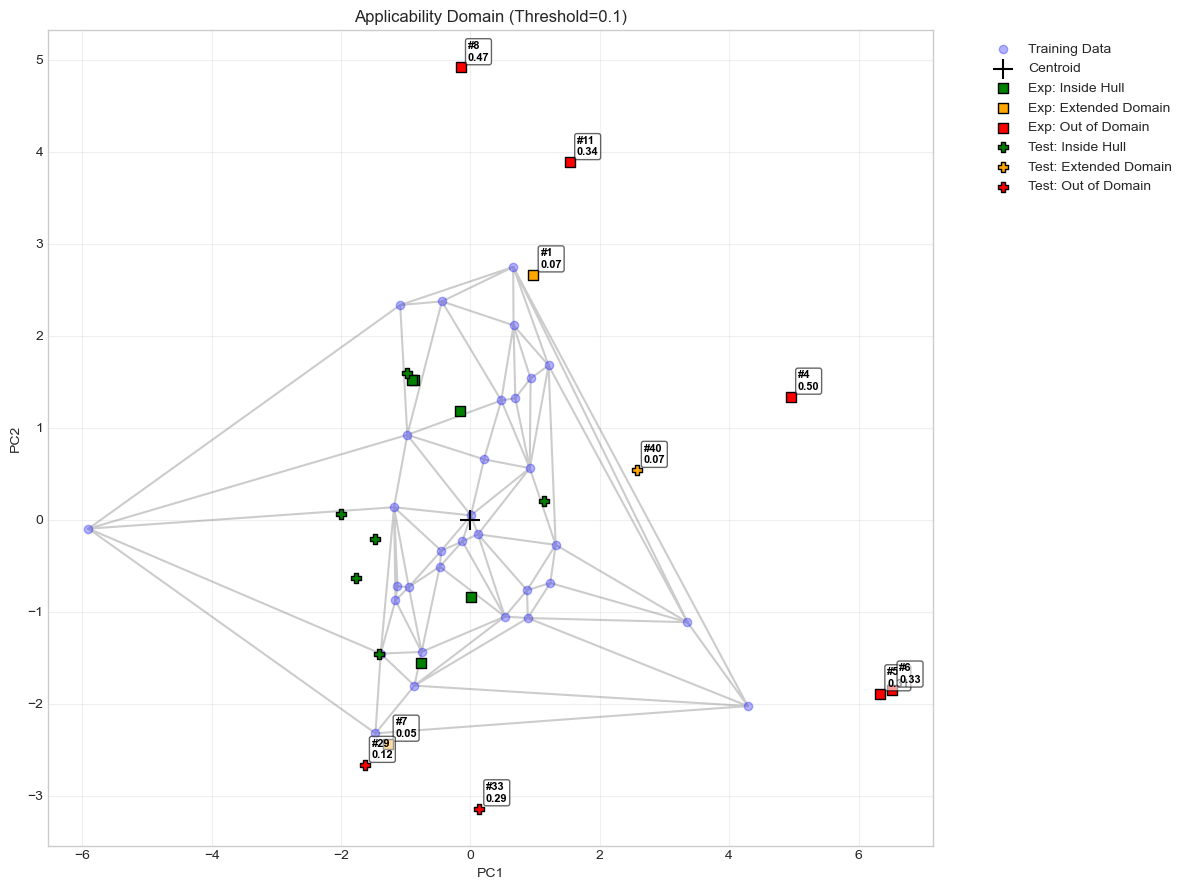


--- Detailed Report: Experimental Set ---
AD_Status
Inside Hull        5
Out of Domain      5
Extended Domain    2
Name: count, dtype: int64

[Extended Domain] Molecules (Index -> Rel_Distance):
  - Index 1: 0.0701
  - Index 7: 0.0456

[Out of Domain] Molecules (Index -> Rel_Distance):
  - Index 4: 0.4997
  - Index 5: 0.3102
  - Index 6: 0.3306
  - Index 8: 0.4671
  - Index 11: 0.3438

--- Detailed Report: Test Set ---
AD_Status
Inside Hull        6
Out of Domain      2
Extended Domain    1
Name: count, dtype: int64

[Extended Domain] Molecules (Index -> Rel_Distance):
  - Index 40: 0.0697

[Out of Domain] Molecules (Index -> Rel_Distance):
  - Index 29: 0.1224
  - Index 33: 0.2859


In [30]:
result = analyze_applicability_heuristic(X_train, data[list(X_train.columns)], X_test, heuristic_threshold=0.1)

In [31]:
result['exp_results_df']

,ATS5s,ATS3i,AMID_C,AATSC4i,nRot,Sterimol_Beta_R1_B5,ATSC7Z,GATS3d,AD_Status,Rel_Distance,Original_Index
0,168.814815,9813.849114,1.820925,-0.167162,4,5.657088,144.476562,1.227520,Extended Domain,0.070081,1
1,134.370370,8694.181498,1.806973,-0.136091,3,5.656860,59.795918,1.237451,Inside Hull,0.000000,2
2,132.348765,8694.181498,1.806876,-0.135418,3,5.635287,59.795918,1.237451,Inside Hull,0.000000,3
3,233.481481,11282.809066,1.667788,0.110417,6,7.136179,93.060487,1.413043,Out of Domain,0.499672,4
4,258.388889,13275.115138,1.678118,0.014147,6,10.560023,14.124331,1.136456,Out of Domain,0.310178,5
5,254.333333,14524.474089,1.679800,0.101721,6,8.632473,83.380952,0.984153,Out of Domain,0.330647,6
6,143.796296,9492.497442,1.810301,-0.142227,3,6.874620,-170.579605,1.096698,Extended Domain,0.045642,7
7,301.027778,9845.072761,1.652118,-0.803920,3,5.670329,53.908429,1.241594,Out of Domain,0.467129,8
8,161.500000,9492.667877,1.812017,-0.220072,4,5.663913,-40.980469,1.317460,Inside Hull,0.000000,9
9,157.666667,9771.362821,1.810301,-0.082216,3,6.040328,-99.099896,1.096698,Inside Hull,0.000000,10


In [32]:
result['test_results_df']

,ATS5s,ATS3i,AMID_C,AATSC4i,nRot,Sterimol_Beta_R1_B5,ATSC7Z,GATS3d,AD_Status,Rel_Distance,Original_Index
index,,,,,,,,,,,
37,129.333333,8077.610614,1.767820,-0.038282,3,5.511457,-47.000000,1.233819,Inside Hull,0.000000,37
13,190.333333,9038.243554,1.860136,-0.009447,1,5.479057,-75.663265,1.178436,Inside Hull,0.000000,13
7,134.129630,8690.008748,1.807554,-0.125359,3,6.659977,-110.204082,1.138455,Inside Hull,0.000000,7
29,126.333333,8852.640435,1.814888,0.107435,3,4.481087,-74.989026,0.930845,Out of Domain,0.122439,29
14,114.333333,7385.685988,1.768326,-0.095792,3,5.663262,-26.014400,1.201923,Inside Hull,0.000000,14
10,175.777778,11144.866298,1.973998,-0.150667,3,8.051359,3.000000,1.212276,Inside Hull,0.000000,10
33,85.333333,9213.058409,1.697269,-0.023298,5,7.253400,-9.000000,0.829082,Out of Domain,0.285869,33
40,213.388889,11858.797464,1.884473,-0.240183,4,8.705143,0.000000,1.247184,Extended Domain,0.069734,40
34,156.777778,9586.692318,1.910930,-0.254818,3,5.620681,-58.899063,1.373753,Inside Hull,0.000000,34


In [33]:
fig = exp_df
fig['predicted_ee'] = y_pred_exp
fig.head()

,l.p,SMILES,SMILES_product,ee,predicted_ee
0,10,C=CC1=CC(/C=C/C(C2=C(C=CC=C2)Br)=O)=CC=C1,C=CC1=CC([C@@H]2O[C@H]2C(C3=C(Br)C=CC=C3)=O)=C...,92,81.532958
1,11,O=C(/C=C/C1=CC=CC=C1)C2=CC=CC=C2Br,O=C(C1=CC=CC=C1Br)[C@H]2[C@H](C3=CC=CC=C3)O2,89,82.789767
2,12,O=C(/C=C/C1=C(Br)C=CC=C1)C2=CC=CC=C2,O=C([C@@H]1[C@H](O1)C2=C(Br)C=CC=C2)C3=CC=CC=C3,11,42.704076
3,13,O=C(/C=C/C1=CC=CC(C(OC)OC)=C1)C2=C(Br)C=CC=C2,O=C(C1=C(C=CC=C1)Br)[C@H]2[C@H](C3=CC=CC(C(OC)...,87,63.668637
4,14,O=C(/C=C/C1=CC=C(OC2=CC=CC=C2)C=C1)C3=CC=C([N+...,O=C(C1=CC=C(C=C1)[N+]([O-])=O)[C@H]2[C@H](C3=C...,90,78.248191


In [34]:
fig['AD_Status'] = result['exp_results_df']['AD_Status']
fig.head()

,l.p,SMILES,SMILES_product,ee,predicted_ee,AD_Status
0,10,C=CC1=CC(/C=C/C(C2=C(C=CC=C2)Br)=O)=CC=C1,C=CC1=CC([C@@H]2O[C@H]2C(C3=C(Br)C=CC=C3)=O)=C...,92,81.532958,Extended Domain
1,11,O=C(/C=C/C1=CC=CC=C1)C2=CC=CC=C2Br,O=C(C1=CC=CC=C1Br)[C@H]2[C@H](C3=CC=CC=C3)O2,89,82.789767,Inside Hull
2,12,O=C(/C=C/C1=C(Br)C=CC=C1)C2=CC=CC=C2,O=C([C@@H]1[C@H](O1)C2=C(Br)C=CC=C2)C3=CC=CC=C3,11,42.704076,Inside Hull
3,13,O=C(/C=C/C1=CC=CC(C(OC)OC)=C1)C2=C(Br)C=CC=C2,O=C(C1=C(C=CC=C1)Br)[C@H]2[C@H](C3=CC=CC(C(OC)...,87,63.668637,Out of Domain
4,14,O=C(/C=C/C1=CC=C(OC2=CC=CC=C2)C=C1)C3=CC=C([N+...,O=C(C1=CC=C(C=C1)[N+]([O-])=O)[C@H]2[C@H](C3=C...,90,78.248191,Out of Domain


In [35]:
from rdkit import Chem
from rdkit.Chem import Draw

from rdkit.Chem.Draw import rdMolDraw2D

def draw_molgrid_with_results(df, 
                              smiles_col='SMILES', 
                              obs_col='ee', 
                              pred_col='predicted_ee',
                              hull_col='AD_Status',
                              n_per_row=4, 
                              max_mols=100, 
                              img_size=(400, 400)):

    mols = []
    legends = []
    
    df_subset = df.head(max_mols)
    
    for idx, row in df_subset.iterrows():
        smi = row[smiles_col]
        obs = row[obs_col]
        pred = row[pred_col]
        hull = row[hull_col]
        
        mol = Chem.MolFromSmiles(smi)
        
        if mol is not None:
            mols.append(mol)
            
            error = abs(obs - pred)

            label = f"Obs: {obs:.1f} | Pred: {pred:.1f} | Err: {error:.1f} \n AD Status: {hull}"
            legends.append(label)
        else:
            print(f"SMILES processing issue for index {idx}: {smi}")

    dopts = rdMolDraw2D.MolDrawOptions()
    
    dopts.legendFontSize = 50  
    
    #dopts.padding = 0.2  

    dopts.bondLineWidth = 4
    

    img = Draw.MolsToGridImage(
        mols, 
        molsPerRow=n_per_row, 
        subImgSize=img_size, 
        legends=legends,
        useSVG=True,
        drawOptions=dopts
    )
    
    return img



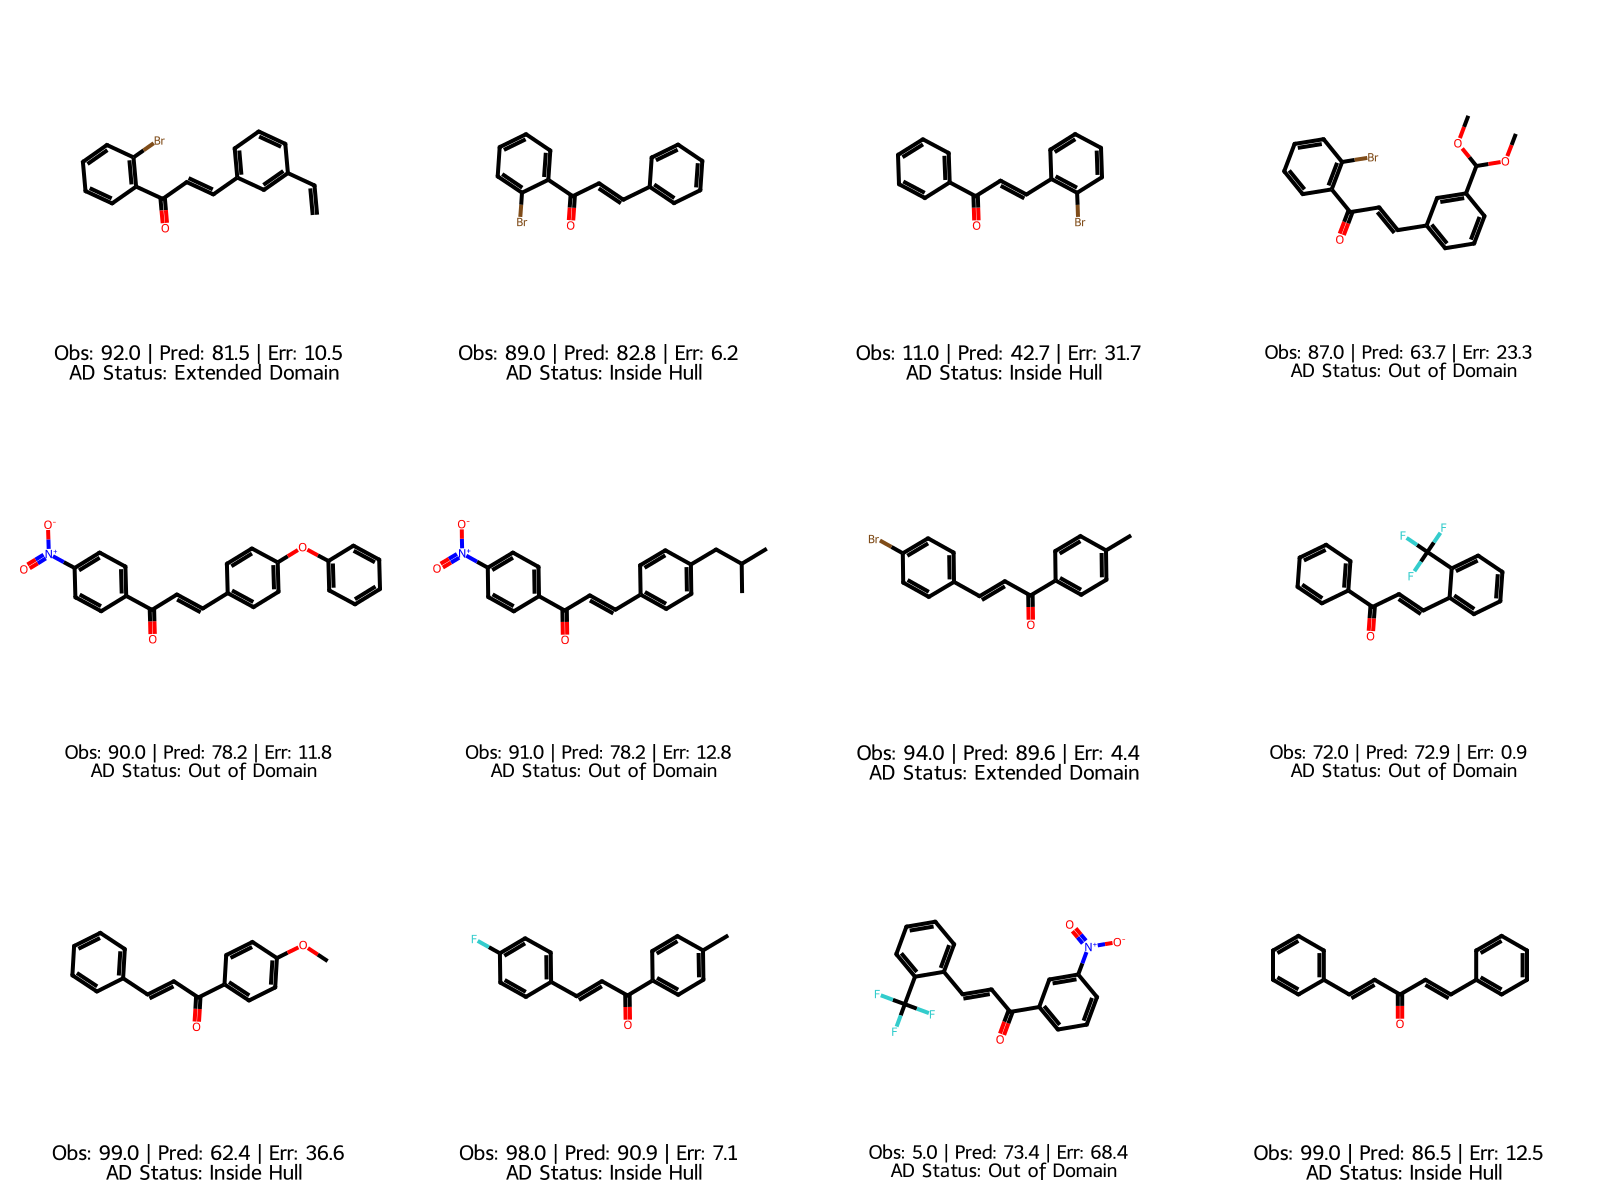

In [36]:
img = draw_molgrid_with_results(fig, max_mols=100)
display(img)

In [37]:
fig['AD_Status'] = result['exp_results_df']['AD_Status']
fig.head()

,l.p,SMILES,SMILES_product,ee,predicted_ee,AD_Status
0,10,C=CC1=CC(/C=C/C(C2=C(C=CC=C2)Br)=O)=CC=C1,C=CC1=CC([C@@H]2O[C@H]2C(C3=C(Br)C=CC=C3)=O)=C...,92,81.532958,Extended Domain
1,11,O=C(/C=C/C1=CC=CC=C1)C2=CC=CC=C2Br,O=C(C1=CC=CC=C1Br)[C@H]2[C@H](C3=CC=CC=C3)O2,89,82.789767,Inside Hull
2,12,O=C(/C=C/C1=C(Br)C=CC=C1)C2=CC=CC=C2,O=C([C@@H]1[C@H](O1)C2=C(Br)C=CC=C2)C3=CC=CC=C3,11,42.704076,Inside Hull
3,13,O=C(/C=C/C1=CC=CC(C(OC)OC)=C1)C2=C(Br)C=CC=C2,O=C(C1=C(C=CC=C1)Br)[C@H]2[C@H](C3=CC=CC(C(OC)...,87,63.668637,Out of Domain
4,14,O=C(/C=C/C1=CC=C(OC2=CC=CC=C2)C=C1)C3=CC=C([N+...,O=C(C1=CC=C(C=C1)[N+]([O-])=O)[C@H]2[C@H](C3=C...,90,78.248191,Out of Domain


In [38]:
fig['ee'][fig['AD_Status'] == 'Inside Hull']

1     89
2     11
8     99
9     98
11    99
Name: ee, dtype: int64

In [39]:
# Calculate metrics for the validation set
exp_r2 = r2_score(fig['ee'][fig['AD_Status'] == 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] == 'Inside Hull'])
exp_rmse = np.sqrt(mean_squared_error(fig['ee'][fig['AD_Status'] == 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] == 'Inside Hull']))

In [40]:
len(fig['ee'][fig['AD_Status'] == 'Inside Hull'])

5

In [41]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  Inside Hull Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {exp_r2:.4f}                  ║")
print(f"║ RMSE            ║   {exp_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

╔═════════════════╦═══════════════════════════╗
║   Metric        ║  Inside Hull Set           ║
╠═════════════════╬═══════════════════════════╣
║ R² (R-squared)  ║   0.5601                  ║
║ RMSE            ║   22.75                   ║
╚═════════════════╩═══════════════════════════╝


In [42]:
# Calculate metrics for the validation set# Calculate metrics for the validation set
exp_r2 = r2_score(fig['ee'][fig['AD_Status'] != 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] != 'Inside Hull'])
exp_rmse = np.sqrt(mean_squared_error(fig['ee'][fig['AD_Status'] != 'Inside Hull'], fig['predicted_ee'][fig['AD_Status'] != 'Inside Hull']))

In [43]:
print("╔═════════════════╦═══════════════════════════╗")
print("║   Metric        ║  Outside Hull Set           ║")
print("╠═════════════════╬═══════════════════════════╣")
print(f"║ R² (R-squared)  ║   {exp_r2:.4f}                  ║")
print(f"║ RMSE            ║   {exp_rmse:.2f}                   ║")
print("╚═════════════════╩═══════════════════════════╝")

╔═════════════════╦═══════════════════════════╗
║   Metric        ║  Outside Hull Set           ║
╠═════════════════╬═══════════════════════════╣
║ R² (R-squared)  ║   0.0859                  ║
║ RMSE            ║   28.41                   ║
╚═════════════════╩═══════════════════════════╝


In [44]:
len(fig['ee'][fig['AD_Status'] != 'Inside Hull'])

7

In [45]:
## see test structure which are outside hull

In [46]:
test = pd.read_excel('./Data/initial_vs_new_SMILES_models_.xlsx')

In [47]:
test.head()

,Unnamed: 0,Initial_SMILES,New_SMILES,ee,dataset,Sterimol_Beta_R1_L,Sterimol_Beta_R1_B1,Sterimol_Beta_R1_B5,Sterimol_Beta_R2_L,Sterimol_Beta_R2_B1,...,Beta_R1_Charge_Head,Beta_R1_Charge_Sum3,Beta_R2_EN,Beta_R2_Charge_Head,Beta_R2_Charge_Sum3,Alpha_R1_EN,Alpha_R1_Charge_Head,Alpha_R1_Charge_Sum3,Diff_Charge_Beta_Alpha,Diff_Charge_Acceptor_Alpha
0,0,CC1=CC=C(/C=C/C(C2=CC=CC=C2)=O)C=C1,C(=C/c1ccc(C)cc1)\C(=O)c1ccccc1,92,train,6.942864,1.7,6.725733,3.441861,1.7,...,-0.025510,-0.131315,2.2,0.063043,-0.001442,2.2,0.066434,0.001950,-0.037687,0.198749
1,1,ClC1=CC=CC=C1/C=C/C(C2=CC=CC=C2)=O,C(=C/c1ccccc1Cl)\C(=O)c1ccccc1,55,train,6.210189,1.7,5.615868,3.441576,1.7,...,-0.006837,-0.109914,2.2,0.063096,0.000160,2.2,0.066435,0.003499,-0.036244,0.198697
2,2,ClC1=CC=C(C=C1)/C=C/C(C2=CC=CC=C2)=O,C(=C/c1ccc(Cl)cc1)\C(=O)c1ccccc1,97,train,7.262086,1.7,6.428952,3.443900,1.7,...,-0.025425,-0.130012,2.2,0.063043,-0.001440,2.2,0.066434,0.001951,-0.037686,0.198749
3,3,O=C(\C=C\C1=CC=CC=C1)C1=CC=CC=C1,C(=C/c1ccccc1)\C(=O)c1ccccc1,97,train,6.610098,1.7,5.664358,3.441967,1.7,...,-0.025529,-0.131598,2.2,0.063043,-0.001442,2.2,0.066434,0.001950,-0.037687,0.198749
4,4,O=C(C1=CC=CC=C1)/C=C/C2=CC=C([N+]([O-])=O)C=C2,C(=C/c1ccc([N+](=O)[O-])cc1)\C(=O)c1ccccc1,79,train,7.632080,1.7,7.224662,3.442040,1.7,...,-0.025030,-0.124259,2.2,0.063043,-0.001434,2.2,0.066434,0.001958,-0.037679,0.198749


In [48]:
test = test[test['dataset'] == 'test']
test

,Unnamed: 0,Initial_SMILES,New_SMILES,ee,dataset,Sterimol_Beta_R1_L,Sterimol_Beta_R1_B1,Sterimol_Beta_R1_B5,Sterimol_Beta_R2_L,Sterimol_Beta_R2_B1,...,Beta_R1_Charge_Head,Beta_R1_Charge_Sum3,Beta_R2_EN,Beta_R2_Charge_Head,Beta_R2_Charge_Sum3,Alpha_R1_EN,Alpha_R1_Charge_Head,Alpha_R1_Charge_Sum3,Diff_Charge_Beta_Alpha,Diff_Charge_Acceptor_Alpha
7,7,BrC1=CC=C(C=C1)/C=C/C(C2=CC=CC=C2)=O,C(=C/c1ccc(Br)cc1)\C(=O)c1ccccc1,95,test,7.469023,1.7,6.659977,3.443871,1.7,...,-0.025451,-0.130396,2.2,0.063043,-0.001441,2.20,0.066434,0.001951,-0.037686,0.198749
10,10,O=C(C1=CC=CC=C1)/C=C/C2=CC3=CC=CC=C3C=C2,C(=C/c1ccc2ccccc2c1)\C(=O)c1ccccc1,96,test,7.020210,1.7,8.051359,3.441873,1.7,...,-0.024890,-0.130298,2.2,0.063043,-0.001419,2.20,0.066434,0.001972,-0.037666,0.198748
13,13,O=C1/C(C(C2=CC=CC=C12)=O)=C\C3=CC=CC=C3,C1(=Cc2ccccc2)C(=O)c2ccccc2C1=O,53,test,6.424245,1.7,5.479057,3.439755,1.7,...,-0.024790,-0.119527,2.2,0.063823,0.095198,2.55,0.197240,-0.057376,-0.110930,0.126088
14,14,O=C(C1=CC=CO1)/C=C/C2=CC=CC=C2,C(=C/c1ccccc1)\C(=O)c1ccco1,93,test,6.590766,1.7,5.663262,3.441975,1.7,...,-0.025527,-0.131472,2.2,0.063045,0.002012,2.20,0.066561,0.005528,-0.040892,0.230574
29,29,CC(C)/C=C/C(C1=CC=CC=C1)=O,C(=C/C(C)C)\C(=O)c1ccccc1,79,test,5.341524,1.7,4.481087,3.443234,1.7,...,-0.028591,-0.165927,2.2,0.057997,-0.037811,2.20,0.066082,-0.029725,-0.060341,0.202754
33,33,CCCCC/C=C/C(C)=O,C(=C/CCCCC)\C(C)=O,70,test,6.487187,1.7,7.253400,3.441638,1.7,...,-0.034635,-0.165480,2.2,0.057707,-0.046611,2.20,0.065668,-0.038650,-0.057730,0.175089
34,34,CC1=CC=CC=C1/C=C/C(C2=CC=CC=C2)=O,C(=C/c1ccccc1C)\C(=O)c1ccccc1,0,test,6.102295,1.7,5.620681,3.441460,1.7,...,-0.022597,-0.128133,2.2,0.063053,-0.001156,2.20,0.066435,0.002226,-0.037431,0.198739
37,37,O=C(C1=CC=CC=C1)/C=C/C2=CC=CN2,C(=C/c1ccc[nH]1)\C(=O)c1ccccc1,0,test,6.177443,1.7,5.511457,3.441492,1.7,...,0.038115,-0.033807,2.2,0.064610,0.017943,2.20,0.066490,0.019824,-0.022804,0.197336
40,40,O=C(/C=C/C1=CC=C(C=C(OC)C=C2)C2=C1)C3=CC=CC=C3,C(=C/c1ccc2cc(OC)ccc2c1)\C(=O)c1ccccc1,97,test,8.708473,1.7,8.705143,3.441903,1.7,...,-0.024890,-0.130296,2.2,0.063043,-0.001419,2.20,0.066434,0.001972,-0.037666,0.198748


In [49]:
test['ee']

7     95
10    96
13    53
14    93
29    79
33    70
34     0
37     0
40    97
Name: ee, dtype: int64

In [50]:
X_test

,ATS5s,ATS3i,AMID_C,AATSC4i,nRot,Sterimol_Beta_R1_B5,ATSC7Z,GATS3d
index,,,,,,,,
37,129.333333,8077.610614,1.767820,-0.038282,3,5.511457,-47.000000,1.233819
13,190.333333,9038.243554,1.860136,-0.009447,1,5.479057,-75.663265,1.178436
7,134.129630,8690.008748,1.807554,-0.125359,3,6.659977,-110.204082,1.138455
29,126.333333,8852.640435,1.814888,0.107435,3,4.481087,-74.989026,0.930845
14,114.333333,7385.685988,1.768326,-0.095792,3,5.663262,-26.014400,1.201923
10,175.777778,11144.866298,1.973998,-0.150667,3,8.051359,3.000000,1.212276
33,85.333333,9213.058409,1.697269,-0.023298,5,7.253400,-9.000000,0.829082
40,213.388889,11858.797464,1.884473,-0.240183,4,8.705143,0.000000,1.247184
34,156.777778,9586.692318,1.910930,-0.254818,3,5.620681,-58.899063,1.373753


In [51]:
pred_test = model.predict(X_test)
pred_test.round(2)

array([44.01, 51.82, 89.64, 50.86, 90.94, 90.6 , 81.88, 68.43, 35.98])

In [52]:
result['test_results_df']

,ATS5s,ATS3i,AMID_C,AATSC4i,nRot,Sterimol_Beta_R1_B5,ATSC7Z,GATS3d,AD_Status,Rel_Distance,Original_Index
index,,,,,,,,,,,
37,129.333333,8077.610614,1.767820,-0.038282,3,5.511457,-47.000000,1.233819,Inside Hull,0.000000,37
13,190.333333,9038.243554,1.860136,-0.009447,1,5.479057,-75.663265,1.178436,Inside Hull,0.000000,13
7,134.129630,8690.008748,1.807554,-0.125359,3,6.659977,-110.204082,1.138455,Inside Hull,0.000000,7
29,126.333333,8852.640435,1.814888,0.107435,3,4.481087,-74.989026,0.930845,Out of Domain,0.122439,29
14,114.333333,7385.685988,1.768326,-0.095792,3,5.663262,-26.014400,1.201923,Inside Hull,0.000000,14
10,175.777778,11144.866298,1.973998,-0.150667,3,8.051359,3.000000,1.212276,Inside Hull,0.000000,10
33,85.333333,9213.058409,1.697269,-0.023298,5,7.253400,-9.000000,0.829082,Out of Domain,0.285869,33
40,213.388889,11858.797464,1.884473,-0.240183,4,8.705143,0.000000,1.247184,Extended Domain,0.069734,40
34,156.777778,9586.692318,1.910930,-0.254818,3,5.620681,-58.899063,1.373753,Inside Hull,0.000000,34


In [53]:
test_ = result['test_results_df']
test_

,ATS5s,ATS3i,AMID_C,AATSC4i,nRot,Sterimol_Beta_R1_B5,ATSC7Z,GATS3d,AD_Status,Rel_Distance,Original_Index
index,,,,,,,,,,,
37,129.333333,8077.610614,1.767820,-0.038282,3,5.511457,-47.000000,1.233819,Inside Hull,0.000000,37
13,190.333333,9038.243554,1.860136,-0.009447,1,5.479057,-75.663265,1.178436,Inside Hull,0.000000,13
7,134.129630,8690.008748,1.807554,-0.125359,3,6.659977,-110.204082,1.138455,Inside Hull,0.000000,7
29,126.333333,8852.640435,1.814888,0.107435,3,4.481087,-74.989026,0.930845,Out of Domain,0.122439,29
14,114.333333,7385.685988,1.768326,-0.095792,3,5.663262,-26.014400,1.201923,Inside Hull,0.000000,14
10,175.777778,11144.866298,1.973998,-0.150667,3,8.051359,3.000000,1.212276,Inside Hull,0.000000,10
33,85.333333,9213.058409,1.697269,-0.023298,5,7.253400,-9.000000,0.829082,Out of Domain,0.285869,33
40,213.388889,11858.797464,1.884473,-0.240183,4,8.705143,0.000000,1.247184,Extended Domain,0.069734,40
34,156.777778,9586.692318,1.910930,-0.254818,3,5.620681,-58.899063,1.373753,Inside Hull,0.000000,34


In [54]:
test_ = test_.join(test[['New_SMILES', 'ee']])
test_

,ATS5s,ATS3i,AMID_C,AATSC4i,nRot,Sterimol_Beta_R1_B5,ATSC7Z,GATS3d,AD_Status,Rel_Distance,Original_Index,New_SMILES,ee
index,,,,,,,,,,,,,
37,129.333333,8077.610614,1.767820,-0.038282,3,5.511457,-47.000000,1.233819,Inside Hull,0.000000,37,C(=C/c1ccc[nH]1)\C(=O)c1ccccc1,0
13,190.333333,9038.243554,1.860136,-0.009447,1,5.479057,-75.663265,1.178436,Inside Hull,0.000000,13,C1(=Cc2ccccc2)C(=O)c2ccccc2C1=O,53
7,134.129630,8690.008748,1.807554,-0.125359,3,6.659977,-110.204082,1.138455,Inside Hull,0.000000,7,C(=C/c1ccc(Br)cc1)\C(=O)c1ccccc1,95
29,126.333333,8852.640435,1.814888,0.107435,3,4.481087,-74.989026,0.930845,Out of Domain,0.122439,29,C(=C/C(C)C)\C(=O)c1ccccc1,79
14,114.333333,7385.685988,1.768326,-0.095792,3,5.663262,-26.014400,1.201923,Inside Hull,0.000000,14,C(=C/c1ccccc1)\C(=O)c1ccco1,93
10,175.777778,11144.866298,1.973998,-0.150667,3,8.051359,3.000000,1.212276,Inside Hull,0.000000,10,C(=C/c1ccc2ccccc2c1)\C(=O)c1ccccc1,96
33,85.333333,9213.058409,1.697269,-0.023298,5,7.253400,-9.000000,0.829082,Out of Domain,0.285869,33,C(=C/CCCCC)\C(C)=O,70
40,213.388889,11858.797464,1.884473,-0.240183,4,8.705143,0.000000,1.247184,Extended Domain,0.069734,40,C(=C/c1ccc2cc(OC)ccc2c1)\C(=O)c1ccccc1,97
34,156.777778,9586.692318,1.910930,-0.254818,3,5.620681,-58.899063,1.373753,Inside Hull,0.000000,34,C(=C/c1ccccc1C)\C(=O)c1ccccc1,0


In [55]:
test_outside = test_
test_outside['AD_Status'] = result['test_results_df']['AD_Status']
test_outside['pred_ee'] = pred_test.round(2)
test_outside['Rel_Distance'] = result['test_results_df']['Rel_Distance']
test_outside = test_outside[test_outside['AD_Status'] != 'Inside Hull']

In [56]:
test_outside

,ATS5s,ATS3i,AMID_C,AATSC4i,nRot,Sterimol_Beta_R1_B5,ATSC7Z,GATS3d,AD_Status,Rel_Distance,Original_Index,New_SMILES,ee,pred_ee
index,,,,,,,,,,,,,,
29,126.333333,8852.640435,1.814888,0.107435,3,4.481087,-74.989026,0.930845,Out of Domain,0.122439,29,C(=C/C(C)C)\C(=O)c1ccccc1,79,50.86
33,85.333333,9213.058409,1.697269,-0.023298,5,7.253400,-9.000000,0.829082,Out of Domain,0.285869,33,C(=C/CCCCC)\C(C)=O,70,81.88
40,213.388889,11858.797464,1.884473,-0.240183,4,8.705143,0.000000,1.247184,Extended Domain,0.069734,40,C(=C/c1ccc2cc(OC)ccc2c1)\C(=O)c1ccccc1,97,68.43


In [57]:
pred_test = model.predict(X_test[X_train.columns])
pred_test.round(2)

array([44.01, 51.82, 89.64, 50.86, 90.94, 90.6 , 81.88, 68.43, 35.98])

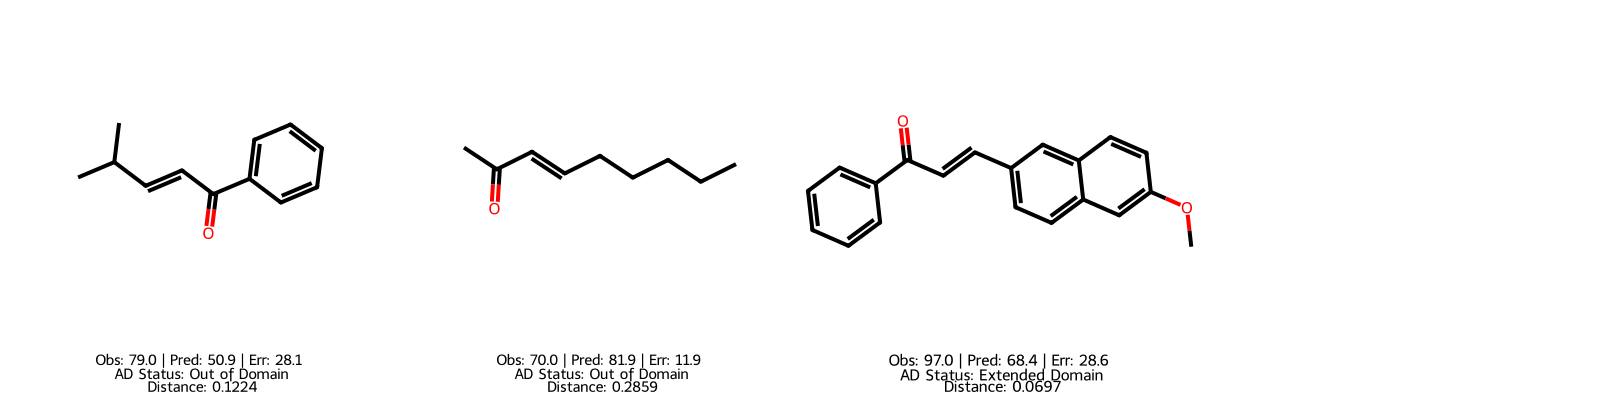

In [58]:

from rdkit import Chem
from rdkit.Chem import Draw

from rdkit.Chem.Draw import rdMolDraw2D

def draw_molgrid_with_results(df, 
                              smiles_col='New_SMILES', 
                              obs_col='ee',
                              pred_col='pred_ee',
                              distance='Rel_Distance',
                              hull_col='AD_Status',
                              n_per_row=4, 
                              max_mols=100, 
                              img_size=(400, 400)):

    mols = []
    legends = []
    
    df_subset = df.head(max_mols)
    
    for idx, row in df_subset.iterrows():
        smi = row[smiles_col]
        obs = row[obs_col]
        pred = row[pred_col]
        dist = row[distance]
        hull = row[hull_col]
        
        mol = Chem.MolFromSmiles(smi)
        
        if mol is not None:
            mols.append(mol)
            
            error = abs(obs - pred)

            label = f"Obs: {obs:.1f} | Pred: {pred:.1f} | Err: {error:.1f} \n AD Status: {hull} \n Distance: {round(dist,4)}"
            legends.append(label)
        else:
            print(f"SMILES processing issue for index {idx}: {smi}")

    dopts = rdMolDraw2D.MolDrawOptions()
    
    #dopts.legendFontSize = 24  
    
    dopts.padding = 0.02  

    dopts.bondLineWidth = 4
    

    img = Draw.MolsToGridImage(
        mols, 
        molsPerRow=n_per_row, 
        subImgSize=img_size, 
        legends=legends,
        useSVG=True,
        drawOptions=dopts
    )
    
    return img


img = draw_molgrid_with_results(test_outside, max_mols=100)
display(img)